In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import norm
from sklearn.decomposition import PCA
from pathlib import Path
from PIL import Image
import os, time

# --- GAUSSSEARCH helpers ---
def symmetrize(A):
    return 0.5 * (A + A.T)

def bisecting_hyperplane(x_i, x_j):
    diff = x_i - x_j
    nrm = np.linalg.norm(diff)
    if nrm < 1e-12:
        w = np.zeros_like(diff); w[0] = 1.0
        return w, 0.0
    w = diff / nrm
    b = (np.dot(x_j, x_j) - np.dot(x_i, x_i)) / (2 * nrm)
    return w, b

def probit_prob(x_i, x_j, x_t, sigma_eps):
    w, b = bisecting_hyperplane(x_i, x_j)
    return norm.cdf((np.dot(x_t, w) + b) / sigma_eps)

def query_oracle(x_i, x_j, x_t, sigma_eps, rng):
    p = probit_prob(x_i, x_j, x_t, sigma_eps)
    return 0 if rng.random() < p else 1

def sample_mirror(mu, Sigma, X, used, rng):
    Sigma = symmetrize(Sigma)
    eigvals, eigvecs = np.linalg.eigh(Sigma)
    w_star = eigvecs[:, -1]
    b_star = -np.dot(w_star, mu)
    z1 = rng.multivariate_normal(mu, Sigma)
    z2 = z1 - 2 * (np.dot(w_star, z1) + b_star) * w_star
    def nearest(z, exclude):
        diffs = X - z
        d2 = np.einsum('nd,nd->n', diffs, diffs)
        for k in exclude:
            d2[k] = np.inf
        return int(np.argmin(d2))
    i = nearest(z1, used)
    j = nearest(z2, used | {i})
    return i, j

def adf_update(mu, Sigma, x_i, x_j, y, sigma_eps):
    w, b = bisecting_hyperplane(x_i, x_j)
    if y == 1:
        w = -w; b = -b
    Sw = Sigma @ w
    wSw = float(w @ Sw)
    denom = np.sqrt(wSw + sigma_eps**2)
    mu_w = float(mu @ w)
    g = (mu_w + b) / denom
    phi_g = norm.pdf(g)
    Phi_g = max(norm.cdf(g), 1e-12)
    alpha = phi_g / (Phi_g * denom)
    beta = -alpha * (g / denom + alpha)
    tau = -beta / (1 + beta * wSw)
    nu = (alpha - beta * (mu_w + b)) / (1 + beta * wSw)
    Sigma_new = Sigma - (tau / (1 + tau * wSw)) * np.outer(Sw, Sw)
    Sigma_new = symmetrize(Sigma_new)
    mu_new = mu + (nu - b * tau - tau * mu_w) * (Sigma_new @ w)
    return mu_new, Sigma_new

def gauss_search_verbose(X, target_idx, sigma_eps, max_queries, rng, stop_on="argmax"):
    n, d = X.shape
    mu = np.zeros(d)
    Sigma = np.eye(d)
    used = set()
    history = {
        "mu": [mu.copy()], "Sigma": [Sigma.copy()],
        "queries": [], "answers": [], "step_stopped": None,
    }
    for step in range(max_queries):
        if stop_on == "argmax":
            diffs = X - mu
            Sigma_inv = np.linalg.inv(Sigma)
            d2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
            if int(np.argmin(d2)) == target_idx:
                history["step_stopped"] = step
                break
        i, j = sample_mirror(mu, Sigma, X, used, rng)
        used |= {i, j}
        y = query_oracle(X[i], X[j], X[target_idx], sigma_eps, rng)
        history["queries"].append((i, j))
        history["answers"].append(y)
        if stop_on == "in_query" and target_idx in (i, j):
            history["step_stopped"] = step + 1
            break
        mu, Sigma = adf_update(mu, Sigma, X[i], X[j], y, sigma_eps)
        history["mu"].append(mu.copy())
        history["Sigma"].append(Sigma.copy())
    return history

# --- Load data ---
PROJECT = Path(r"C:\Users\shlok\projects\ddp-llm\scenery-search")
DATA = PROJECT / "data"

data = np.load(DATA / "scenery_embedding.npz", allow_pickle=True)
X = data["E_work"]
paths = data["paths"]
labels = data["labels"]
n, d = X.shape
print(f"loaded {n} items, working dim = {d}")

# --- Fit 3D PCA fresh ---
pca_3d = PCA(n_components=3, random_state=0)
xyz_3d = pca_3d.fit_transform(X)
pca_P_3d = pca_3d.components_          # (3, d)
pca_mean_3d = pca_3d.mean_             # (d,)

variance_3d = pca_3d.explained_variance_ratio_.sum()
print(f"3D PCA fit: xyz shape {xyz_3d.shape}, variance retained: {variance_3d:.1%}")
print(f"per-component variance: {pca_3d.explained_variance_ratio_}")

def project_belief_3d(mu, Sigma, P, mean):
    mu_p = P @ (mu - mean)
    Sigma_p = P @ Sigma @ P.T
    return mu_p, Sigma_p

SIGMA_EPS = 0.05

loaded 600 items, working dim = 10
3D PCA fit: xyz shape (600, 3), variance retained: 56.0%
per-component variance: [0.26831895 0.16400762 0.12795955]


In [3]:
# find a search with a good step count for viz
runs = []
for trial in range(50):
    rng_trial = np.random.default_rng(seed=1000 + trial)
    target_idx = int(rng_trial.integers(0, n))
    h = gauss_search_verbose(X, target_idx, SIGMA_EPS, max_queries=100,
                              rng=rng_trial, stop_on="argmax")
    runs.append((h["step_stopped"], target_idx, trial, h))

converged = [r for r in runs if r[0] is not None]
converged.sort(key=lambda r: r[0])
lengths = [r[0] for r in converged]
print(f"converged: {len(converged)}/50")
print(f"steps: min={lengths[0]}, median={lengths[len(lengths)//2]}, "
      f"mean={np.mean(lengths):.1f}, max={lengths[-1]}")

# pick around p60 — long enough to show convergence, not pathological
chosen = converged[int(len(converged) * 0.6)]
steps, target_idx, trial, history = chosen
print(f"\nchosen trial {trial}: target={target_idx} ({labels[target_idx]}), steps={steps}")

# diagnostic: how does belief look in 3D across the search?
print(f"\n{'step':>5}  {'||µ_3d - tgt||':>15}  {'tr(Σ_3d)':>10}  {'tr(Σ_10d)':>10}")
step_marks = list(range(0, len(history["mu"]), max(1, len(history["mu"])//8))) + [len(history["mu"])-1]
step_marks = sorted(set(step_marks))
for step in step_marks:
    mu = history["mu"][step]
    Sigma = history["Sigma"][step]
    mu_3d, Sigma_3d = project_belief_3d(mu, Sigma, pca_P_3d, pca_mean_3d)
    dist_3d = np.linalg.norm(mu_3d - xyz_3d[target_idx])
    tr_3d = np.trace(Sigma_3d)
    tr_10 = np.trace(Sigma)
    print(f"{step:>5}  {dist_3d:>15.4f}  {tr_3d:>10.4f}  {tr_10:>10.4f}")

converged: 50/50
steps: min=3, median=24, mean=32.4, max=87

chosen trial 40: target=182 (forest), steps=30

 step   ||µ_3d - tgt||    tr(Σ_3d)   tr(Σ_10d)
    0           0.3560      3.0000     10.0000
    3           0.5202      2.3106      8.0967
    6           0.8690      1.8396      6.2615
    9           1.0303      1.5695      4.7620
   12           1.2261      1.2009      4.1026
   15           1.4135      0.9621      3.2444
   18           1.4264      0.7763      2.4251
   21           1.6291      0.5620      1.8985
   24           1.6658      0.5286      1.7248
   27           1.4378      0.4364      1.2897
   30           1.3797      0.3741      1.0035


In [4]:
print(f"target: idx={target_idx} ({labels[target_idx]}) in {d}-d space")
print(f"target position (first 5 dims): {X[target_idx][:5]}")
print()
print(f"{'step':>5}  {'||µ_10d - tgt||':>15}  {'||µ_3d - tgt||':>15}  {'tr(Σ_10d)':>10}")
for step in range(len(history["mu"])):
    mu = history["mu"][step]
    Sigma = history["Sigma"][step]
    dist_10d = np.linalg.norm(mu - X[target_idx])
    mu_3d, _ = project_belief_3d(mu, Sigma, pca_P_3d, pca_mean_3d)
    dist_3d = np.linalg.norm(mu_3d - xyz_3d[target_idx])
    tr_10 = np.trace(Sigma)
    print(f"{step:>5}  {dist_10d:>15.4f}  {dist_3d:>15.4f}  {tr_10:>10.4f}")

target: idx=182 (forest) in 10-d space
target position (first 5 dims): [-0.18981718 -0.24987747  0.16807972 -0.0412269  -0.05714589]

 step  ||µ_10d - tgt||   ||µ_3d - tgt||   tr(Σ_10d)
    0           0.3896           0.3560     10.0000
    1           0.8927           0.5941      9.3923
    2           1.1621           0.8114      8.7490
    3           1.3579           0.5202      8.0967
    4           1.4219           0.8640      7.4836
    5           1.6150           0.8693      6.8737
    6           1.8160           0.8690      6.2615
    7           1.9266           1.0818      5.7992
    8           2.0515           0.9766      5.3341
    9           2.1441           1.0303      4.7620
   10           2.2106           1.1165      4.4045
   11           2.2247           1.1908      4.2927
   12           2.2318           1.2261      4.1026
   13           2.2200           1.4013      3.8454
   14           2.2092           1.4981      3.6190
   15           2.1178           1

In [5]:
print(f"data mean per-dim:")
print(f"  {X.mean(axis=0)}")
print()
print(f"norm of data centroid: {np.linalg.norm(X.mean(axis=0)):.6f}")
print(f"typical row norm (from origin): {np.linalg.norm(X, axis=1).mean():.4f}")
print(f"typical distance to centroid: {np.linalg.norm(X - X.mean(axis=0), axis=1).mean():.4f}")

data mean per-dim:
  [-4.0580829e-08 -1.1424223e-08  2.8933087e-09 -4.6547502e-08
  3.7369318e-08 -2.0827477e-08 -3.5514436e-08  1.6484410e-08
  1.0256966e-08 -1.2641152e-08]

norm of data centroid: 0.000000
typical row norm (from origin): 0.4095
typical distance to centroid: 0.4095


In [6]:
# rescale globally so per-dim std ≈ 1
X_scale = X.std(axis=0).mean()
print(f"before: mean per-dim std = {X.std(axis=0).mean():.4f}")
X = X / X_scale
print(f"after: mean per-dim std = {X.std(axis=0).mean():.4f}")
print(f"after: typical row norm = {np.linalg.norm(X, axis=1).mean():.4f}")
print(f"prior N(0,I) at d=10: expects {np.sqrt(10):.2f}")

# also need to rescale xyz_3d and pca_mean_3d consistently
xyz_3d = xyz_3d / X_scale
pca_mean_3d = pca_mean_3d / X_scale
# pca_P_3d doesn't change — it's a rotation, not a scale

before: mean per-dim std = 0.1250
after: mean per-dim std = 1.0000
after: typical row norm = 3.2762
prior N(0,I) at d=10: expects 3.16


In [7]:
def measure_flip_rate(X, sigma_eps, n_samples=5000, seed=0):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    flips = 0
    for _ in range(n_samples):
        i, j, t = rng.choice(n, size=3, replace=False)
        x_i, x_j, x_t = X[i], X[j], X[t]
        true_ans = 0 if np.linalg.norm(x_i - x_t) < np.linalg.norm(x_j - x_t) else 1
        noisy_ans = query_oracle(x_i, x_j, x_t, sigma_eps, rng)
        if true_ans != noisy_ans:
            flips += 1
    return flips / n_samples

In [8]:
print("recalibrating sigma_eps on rescaled X...")
print(f"{'sigma_eps':>10s}  {'flip rate':>10s}")
for sigma in [0.05, 0.10, 0.20, 0.35, 0.50, 0.75, 1.0]:
    fr = measure_flip_rate(X, sigma)
    print(f"{sigma:>10.2f}  {fr:>10.1%}")

recalibrating sigma_eps on rescaled X...
 sigma_eps   flip rate
      0.05        1.1%
      0.10        2.5%
      0.20        4.9%
      0.35        8.1%
      0.50       11.5%
      0.75       16.1%
      1.00       20.5%


In [9]:
SIGMA_EPS = 0.45

rng = np.random.default_rng(seed=42)
target_idx = int(rng.integers(0, n))
history = gauss_search_verbose(X, target_idx, SIGMA_EPS, max_queries=100,
                                rng=rng, stop_on="argmax")

print(f"target: idx={target_idx} ({labels[target_idx]}), steps={history['step_stopped']}")
print()
print(f"{'step':>5}  {'||µ_10d - tgt||':>15}  {'tr(Σ_10d)':>10}")
for step in range(len(history["mu"])):
    mu = history["mu"][step]
    Sigma = history["Sigma"][step]
    dist_10d = np.linalg.norm(mu - X[target_idx])
    tr_10 = np.trace(Sigma)
    print(f"{step:>5}  {dist_10d:>15.4f}  {tr_10:>10.4f}")

print()
print("class trace:")
for k, (i, j) in enumerate(history["queries"]):
    ans = history["answers"][k]
    chosen_cls = labels[i] if ans == 0 else labels[j]
    print(f"  step {k}: ({labels[i]:9s}, {labels[j]:9s}) -> chose {chosen_cls}")

target: idx=53 (buildings), steps=32

 step  ||µ_10d - tgt||   tr(Σ_10d)
    0           4.0567     10.0000
    1           4.0156      9.7872
    2           4.1008      9.2461
    3           3.9384      8.8264
    4           4.0036      8.2899
    5           4.0240      7.9411
    6           3.9188      7.5034
    7           3.5908      7.0378
    8           3.3779      6.7107
    9           3.3161      6.3746
   10           3.3687      6.0026
   11           3.4661      5.8257
   12           3.0124      5.3733
   13           2.8878      5.1194
   14           2.7645      4.6499
   15           2.7995      4.2691
   16           2.6497      3.9835
   17           2.4885      3.7256
   18           2.1419      3.4886
   19           2.0098      3.3940
   20           1.9015      3.2708
   21           1.9087      3.1899
   22           1.8367      3.0962
   23           1.5258      2.9381
   24           1.5142      2.8455
   25           1.5441      2.7548
   26           1

In [10]:
print(f"{'step':>5}  {'||µ_10d - tgt||':>15}  {'||µ_3d - tgt||':>15}  {'tr(Σ_3d)':>10}")
for step in [0, 5, 10, 15, 20, 25, 30, 32]:
    if step >= len(history["mu"]):
        continue
    mu = history["mu"][step]
    Sigma = history["Sigma"][step]
    mu_3d, Sigma_3d = project_belief_3d(mu, Sigma, pca_P_3d, pca_mean_3d)
    dist_10d = np.linalg.norm(mu - X[target_idx])
    dist_3d = np.linalg.norm(mu_3d - xyz_3d[target_idx])
    tr_3d = np.trace(Sigma_3d)
    print(f"{step:>5}  {dist_10d:>15.4f}  {dist_3d:>15.4f}  {tr_3d:>10.4f}")

 step  ||µ_10d - tgt||   ||µ_3d - tgt||    tr(Σ_3d)
    0           4.0567           1.5074      3.0000
    5           4.0240           1.2136      2.4469
   10           3.3687           0.5517      1.7741
   15           2.7995           0.2509      1.2221
   20           1.9015           0.2051      0.9218
   25           1.5441           0.3424      0.7893
   30           1.3799           0.4639      0.7084
   32           1.3643           0.6711      0.6476


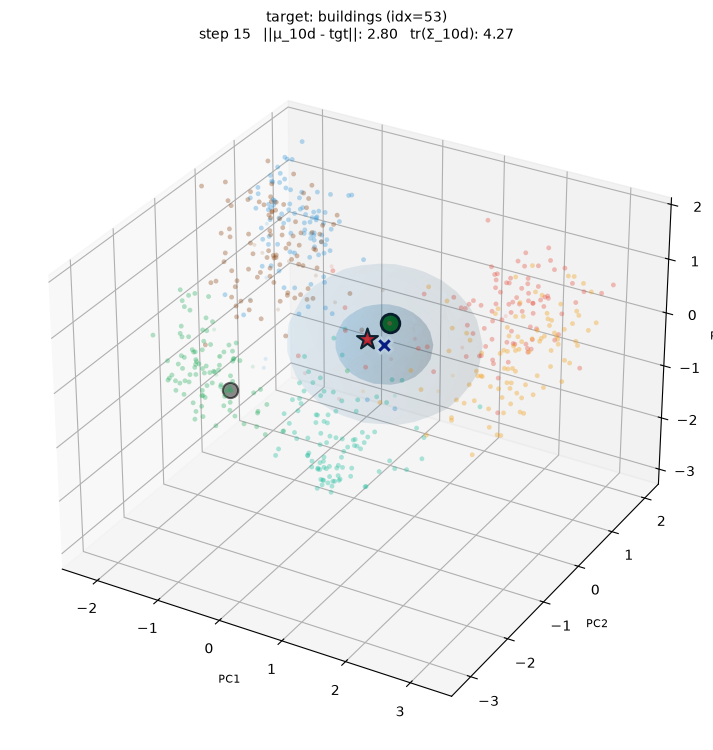

In [11]:
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

class_colors = {
    'buildings': '#e74c3c', 'forest':    '#27ae60',
    'glacier':   '#3498db', 'mountain':  '#8b4513',
    'sea':       '#1abc9c', 'street':    '#f39c12',
}

def plot_step_3d(ax, step, history, xyz_3d, target_idx, labels,
                 pca_P_3d, pca_mean_3d, sigma_eps, X):
    ax.clear()
    mu = history["mu"][step]
    Sigma = history["Sigma"][step]
    queries_so_far = history["queries"][:step]
    current_query = history["queries"][step] if step < len(history["queries"]) else None
    current_answer = history["answers"][step] if step < len(history["answers"]) else None
    
    mu_3d, Sigma_3d = project_belief_3d(mu, Sigma, pca_P_3d, pca_mean_3d)
    
    used_prev = set()
    for (i, j) in queries_so_far:
        used_prev.add(i); used_prev.add(j)
    if current_query is not None:
        used_prev.discard(current_query[0])
        used_prev.discard(current_query[1])
    
    chosen_idx, rejected_idx = None, None
    if current_query is not None and current_answer is not None:
        i, j = current_query
        chosen_idx = i if current_answer == 0 else j
        rejected_idx = j if current_answer == 0 else i
    
    # all items — small dots colored by class
    for cls, color in class_colors.items():
        mask = np.array([lbl == cls for lbl in labels])
        # dim if used, normal otherwise
        for is_used, alpha, size in [(False, 0.35, 12), (True, 0.15, 8)]:
            item_mask = mask & np.array([(k in used_prev) == is_used for k in range(len(labels))])
            if item_mask.any():
                ax.scatter(xyz_3d[item_mask, 0], xyz_3d[item_mask, 1], xyz_3d[item_mask, 2],
                           c=color, s=size, alpha=alpha, edgecolors='none', depthshade=False)
    
    # current query — chosen (green) and rejected (gray)
    if chosen_idx is not None:
        ax.scatter([xyz_3d[chosen_idx, 0]], [xyz_3d[chosen_idx, 1]], [xyz_3d[chosen_idx, 2]],
                   c='#006400', s=180, edgecolors='black', linewidths=2,
                   depthshade=False, zorder=10)
    if rejected_idx is not None:
        ax.scatter([xyz_3d[rejected_idx, 0]], [xyz_3d[rejected_idx, 1]], [xyz_3d[rejected_idx, 2]],
                   c='#404040', s=120, alpha=0.6, edgecolors='black', linewidths=1.5,
                   depthshade=False, zorder=10)
    
    # target — red star
    ax.scatter([xyz_3d[target_idx, 0]], [xyz_3d[target_idx, 1]], [xyz_3d[target_idx, 2]],
               c='red', s=250, marker='*', edgecolors='black', linewidths=1.5,
               depthshade=False, zorder=11)
    
    # belief mean — navy X
    ax.scatter([mu_3d[0]], [mu_3d[1]], [mu_3d[2]],
               c='navy', s=140, marker='X', edgecolors='white', linewidths=2,
               depthshade=False, zorder=11)
    
    # belief 1σ ellipsoid — as scatter of surface points (matplotlib can't do 3d ellipsoid natively)
    eigvals, eigvecs = np.linalg.eigh(Sigma_3d)
    u = np.linspace(0, 2*np.pi, 20)
    v = np.linspace(0, np.pi, 15)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    for n_std, alpha in [(2, 0.06), (1, 0.12)]:
        radii = n_std * np.sqrt(np.maximum(eigvals, 1e-12))
        ellipsoid = np.stack([xs.flatten() * radii[0],
                              ys.flatten() * radii[1],
                              zs.flatten() * radii[2]], axis=0)
        ellipsoid = eigvecs @ ellipsoid + mu_3d[:, None]
        ax.plot_surface(ellipsoid[0].reshape(xs.shape),
                        ellipsoid[1].reshape(xs.shape),
                        ellipsoid[2].reshape(xs.shape),
                        color='#3498db', alpha=alpha, linewidth=0, antialiased=True)
    
    # annotation
    dist_10d = np.linalg.norm(mu - X[target_idx])
    ann = f"step {step}   ||µ_10d - tgt||: {dist_10d:.2f}   tr(Σ_10d): {np.trace(Sigma):.2f}"
    ax.set_title(f"target: {labels[target_idx]} (idx={target_idx})\n{ann}", fontsize=10)
    
    # axis limits — fixed across frames
    ax.set_xlim(xyz_3d[:, 0].min() - 0.05, xyz_3d[:, 0].max() + 0.05)
    ax.set_ylim(xyz_3d[:, 1].min() - 0.05, xyz_3d[:, 1].max() + 0.05)
    ax.set_zlim(xyz_3d[:, 2].min() - 0.05, xyz_3d[:, 2].max() + 0.05)
    ax.set_xlabel("PC1", fontsize=8)
    ax.set_ylabel("PC2", fontsize=8)
    ax.set_zlabel("PC3", fontsize=8)


# smoke test — render one step
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')
plot_step_3d(ax, step=15, history=history, xyz_3d=xyz_3d, target_idx=target_idx,
             labels=labels, pca_P_3d=pca_P_3d, pca_mean_3d=pca_mean_3d,
             sigma_eps=SIGMA_EPS, X=X)
plt.show()

In [12]:
import matplotlib.animation as animation
import matplotlib
import imageio_ffmpeg

matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

def make_3d_animation(history, xyz_3d, target_idx, labels, pca_P_3d, pca_mean_3d,
                      sigma_eps, X, interval_ms=1500):
    n_total = len(history["mu"])
    fig = plt.figure(figsize=(10, 9))
    ax = fig.add_subplot(111, projection='3d')
    
    def draw_frame(step):
        plot_step_3d(ax, step, history, xyz_3d, target_idx, labels,
                     pca_P_3d, pca_mean_3d, sigma_eps, X)
        return []
    
    anim = animation.FuncAnimation(fig, draw_frame, frames=n_total,
                                    interval=interval_ms, blit=False, repeat=True)
    plt.close(fig)
    return anim

anim_3d = make_3d_animation(history, xyz_3d, target_idx, labels,
                             pca_P_3d, pca_mean_3d, SIGMA_EPS, X, interval_ms=1500)

import tempfile, uuid
from IPython.display import Video

tmp_mp4 = os.path.join(tempfile.gettempdir(), f"scenery_3d_{uuid.uuid4().hex[:8]}.mp4")
anim_3d.save(tmp_mp4, writer='ffmpeg', fps=0.67, dpi=100)  # 1.5s per frame
print(f"saved to {tmp_mp4}")

Video(tmp_mp4, embed=True, width=700)

saved to C:\Users\shlok\AppData\Local\Temp\scenery_3d_2c14cdac.mp4


In [13]:
# score every candidate: high 3D distance from origin (visually far) + inside dense cluster
target_scores = []
for r in converged:
    steps, idx, trial, h = r
    dist_from_origin_3d = np.linalg.norm(xyz_3d[idx])
    # count how many same-class neighbors are within some radius
    same_class = np.array([lbl == labels[idx] for lbl in labels])
    dists_to_others = np.linalg.norm(xyz_3d - xyz_3d[idx], axis=1)
    n_close_same_class = np.sum(same_class & (dists_to_others < 0.5))
    target_scores.append((dist_from_origin_3d, n_close_same_class, steps, idx, trial, h))

# sort by (far from origin AND deep in cluster AND moderate step count)
target_scores.sort(key=lambda s: -s[0] * (s[1] + 1))
print(f"top 10 candidates:")
print(f"{'dist_orig':>10} {'#nbrs':>6} {'steps':>6} {'idx':>5} {'class':>10}")
for s in target_scores[:10]:
    dist, n_close, steps, idx, trial, _ = s
    print(f"{dist:>10.3f} {n_close:>6} {steps:>6} {idx:>5} {labels[idx]:>10}")

# pick the top one that has 15-40 steps (long enough for animation, not pathological)
good_candidates = [s for s in target_scores if 15 <= s[2] <= 40]
if good_candidates:
    chosen = good_candidates[0]
    dist, n_close, steps, target_idx, trial, history = chosen
    print(f"\nchosen: idx={target_idx} ({labels[target_idx]}), steps={steps}")
    print(f"  distance from origin (3d): {dist:.3f}")
    print(f"  same-class neighbors within 0.5: {n_close}")
else:
    print("no candidate with 15-40 steps found")

top 10 candidates:
 dist_orig  #nbrs  steps   idx      class
     3.049     30     14   171     forest
     2.815     30     70   441        sea
     2.691     26     52   118     forest
     2.642     22     20   437        sea
     2.718     18     76    86  buildings
     2.665     18     21   237    glacier
     2.918     16     15   256    glacier
     2.627     17     18   122     forest
     2.450     17     70   452        sea
     2.756     15     16   178     forest

chosen: idx=437 (sea), steps=20
  distance from origin (3d): 2.642
  same-class neighbors within 0.5: 22


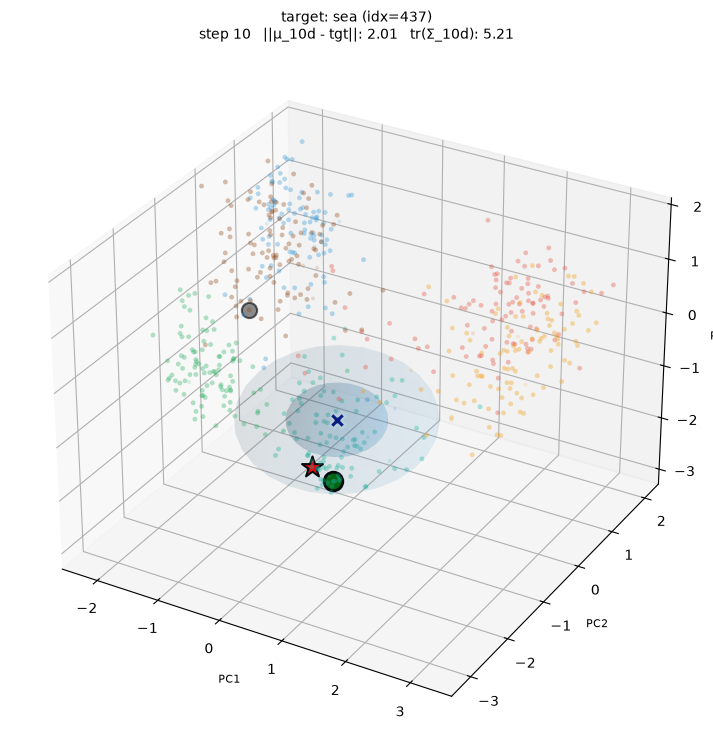

In [14]:
# smoke test — render step 10 with the new target
fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')
plot_step_3d(ax, step=10, history=history, xyz_3d=xyz_3d, target_idx=target_idx,
             labels=labels, pca_P_3d=pca_P_3d, pca_mean_3d=pca_mean_3d,
             sigma_eps=SIGMA_EPS, X=X)
plt.show()


In [15]:
anim_3d = make_3d_animation(history, xyz_3d, target_idx, labels,
                             pca_P_3d, pca_mean_3d, SIGMA_EPS, X, interval_ms=1500)

tmp_mp4 = os.path.join(tempfile.gettempdir(), f"scenery_3d_{uuid.uuid4().hex[:8]}.mp4")
anim_3d.save(tmp_mp4, writer='ffmpeg', fps=0.67, dpi=100)
print(f"saved to {tmp_mp4}")

Video(tmp_mp4, embed=True, width=700)

saved to C:\Users\shlok\AppData\Local\Temp\scenery_3d_1adc4236.mp4


In [16]:
print(f"running 600 searches (one per target) at sigma_eps={SIGMA_EPS}, argmax stopping...")
print("this will take ~2-5 minutes")

t0 = time.time()
all_steps = []
unconverged = 0

for target_i in range(n):
    rng_i = np.random.default_rng(seed=10000 + target_i)
    h = gauss_search_verbose(X, target_i, SIGMA_EPS, max_queries=200,
                              rng=rng_i, stop_on="argmax")
    if h["step_stopped"] is None:
        unconverged += 1
        all_steps.append(200)  # cap for stats
    else:
        all_steps.append(h["step_stopped"])

elapsed = time.time() - t0
print(f"\ndone in {elapsed:.1f}s")
print(f"unconverged (hit 200-query cap): {unconverged}/{n}")

arr = np.array(all_steps)
print(f"\n--- overall stats ---")
print(f"  mean:     {arr.mean():.2f}")
print(f"  median:   {np.median(arr):.1f}")
print(f"  std:      {arr.std():.2f}")
print(f"  variance: {arr.var():.2f}")
print(f"  min:      {arr.min()}")
print(f"  max:      {arr.max()}")

print(f"\n--- percentiles ---")
for p in [10, 25, 50, 75, 90, 95, 99]:
    print(f"  p{p:>2}: {np.percentile(arr, p):.1f}")

print(f"\n--- per-class breakdown ---")
labels_arr = np.array(labels)
for cls in np.unique(labels_arr):
    mask = labels_arr == cls
    cls_steps = arr[mask]
    print(f"  {cls:9s}: mean={cls_steps.mean():5.1f}  median={np.median(cls_steps):5.1f}  "
          f"max={cls_steps.max():3d}  n={mask.sum()}")

running 600 searches (one per target) at sigma_eps=0.45, argmax stopping...
this will take ~2-5 minutes

done in 21.4s
unconverged (hit 200-query cap): 0/600

--- overall stats ---
  mean:     27.58
  median:   22.0
  std:      20.96
  variance: 439.32
  min:      0
  max:      172

--- percentiles ---
  p10: 10.0
  p25: 14.0
  p50: 22.0
  p75: 33.0
  p90: 50.0
  p95: 69.0
  p99: 107.0

--- per-class breakdown ---
  buildings: mean= 22.5  median= 22.0  max= 69  n=100
  forest   : mean= 33.7  median= 25.0  max=111  n=100
  glacier  : mean= 33.4  median= 23.5  max=172  n=100
  mountain : mean= 25.0  median= 22.0  max= 94  n=100
  sea      : mean= 24.1  median= 20.5  max= 83  n=100
  street   : mean= 26.8  median= 23.0  max=116  n=100


In [17]:
def rand_search(X, target_idx, sigma_eps, max_queries, rng, stop_on="argmax"):
    """Same infrastructure as gauss_search, but query pair chosen uniformly at random."""
    n, d = X.shape
    mu = np.zeros(d)
    Sigma = np.eye(d)
    used = set()
    step_stopped = None
    for step in range(max_queries):
        if stop_on == "argmax":
            diffs = X - mu
            Sigma_inv = np.linalg.inv(Sigma)
            d2 = np.einsum('nd,de,ne->n', diffs, Sigma_inv, diffs)
            if int(np.argmin(d2)) == target_idx:
                step_stopped = step
                break
        available = [k for k in range(n) if k not in used]
        if len(available) < 2:
            break
        i, j = rng.choice(available, size=2, replace=False)
        i, j = int(i), int(j)
        used |= {i, j}
        y = query_oracle(X[i], X[j], X[target_idx], sigma_eps, rng)
        if stop_on == "in_query" and target_idx in (i, j):
            step_stopped = step + 1
            break
        mu, Sigma = adf_update(mu, Sigma, X[i], X[j], y, sigma_eps)
    return step_stopped

print(f"running 600 RAND searches at sigma_eps={SIGMA_EPS}, argmax stopping...")
t0 = time.time()
rand_steps = []
rand_unconverged = 0

for target_i in range(n):
    rng_i = np.random.default_rng(seed=20000 + target_i)
    s = rand_search(X, target_i, SIGMA_EPS, max_queries=500, rng=rng_i, stop_on="argmax")
    if s is None:
        rand_unconverged += 1
        rand_steps.append(500)
    else:
        rand_steps.append(s)

print(f"done in {time.time()-t0:.1f}s")
print(f"unconverged: {rand_unconverged}/{n}")

rand_arr = np.array(rand_steps)
print(f"\n--- RAND stats ---")
print(f"  mean:   {rand_arr.mean():.2f}")
print(f"  median: {np.median(rand_arr):.1f}")
print(f"  std:    {rand_arr.std():.2f}")
print(f"  max:    {rand_arr.max()}")
for p in [50, 75, 90, 95]:
    print(f"  p{p}:    {np.percentile(rand_arr, p):.1f}")

print(f"\n--- head-to-head ---")
print(f"  {'':>15} {'GAUSSSEARCH':>15} {'RAND':>15} {'ratio':>10}")
print(f"  {'mean':>15} {arr.mean():>15.2f} {rand_arr.mean():>15.2f} {rand_arr.mean()/arr.mean():>10.2f}x")
print(f"  {'median':>15} {np.median(arr):>15.1f} {np.median(rand_arr):>15.1f} "
      f"{np.median(rand_arr)/np.median(arr):>10.2f}x")
print(f"  {'p90':>15} {np.percentile(arr,90):>15.1f} {np.percentile(rand_arr,90):>15.1f} "
      f"{np.percentile(rand_arr,90)/np.percentile(arr,90):>10.2f}x")

running 600 RAND searches at sigma_eps=0.45, argmax stopping...
done in 31.7s
unconverged: 8/600

--- RAND stats ---
  mean:   58.40
  median: 37.0
  std:    69.00
  max:    500
  p50:    37.0
  p75:    70.2
  p90:    119.1
  p95:    162.0

--- head-to-head ---
                      GAUSSSEARCH            RAND      ratio
             mean           27.58           58.40       2.12x
           median            22.0            37.0       1.68x
              p90            50.0           119.1       2.38x


In [18]:
print(f"running 600 GAUSSSEARCH searches at sigma_eps={SIGMA_EPS}, IN_QUERY stopping...")
t0 = time.time()

gauss_iq_steps = []
gauss_iq_unconverged = 0
for target_i in range(n):
    rng_i = np.random.default_rng(seed=10000 + target_i)
    h = gauss_search_verbose(X, target_i, SIGMA_EPS, max_queries=200,
                              rng=rng_i, stop_on="in_query")
    if h["step_stopped"] is None:
        gauss_iq_unconverged += 1
        gauss_iq_steps.append(200)
    else:
        gauss_iq_steps.append(h["step_stopped"])

print(f"done in {time.time()-t0:.1f}s")
print(f"unconverged: {gauss_iq_unconverged}/{n}")

gauss_iq = np.array(gauss_iq_steps)
print(f"\n--- GAUSSSEARCH in_query stats ---")
print(f"  mean:   {gauss_iq.mean():.2f}")
print(f"  median: {np.median(gauss_iq):.1f}")
print(f"  std:    {gauss_iq.std():.2f}")
print(f"  min:    {gauss_iq.min()}")
print(f"  max:    {gauss_iq.max()}")
for p in [25, 50, 75, 90, 95, 99]:
    print(f"  p{p:>2}: {np.percentile(gauss_iq, p):.1f}")

running 600 GAUSSSEARCH searches at sigma_eps=0.45, IN_QUERY stopping...
done in 8.7s
unconverged: 0/600

--- GAUSSSEARCH in_query stats ---
  mean:   16.85
  median: 17.0
  std:    6.89
  min:    1
  max:    43
  p25: 12.0
  p50: 17.0
  p75: 21.0
  p90: 26.0
  p95: 29.0
  p99: 35.0


In [19]:
print(f"running 600 RAND searches at sigma_eps={SIGMA_EPS}, IN_QUERY stopping...")
t0 = time.time()

rand_iq_steps = []
rand_iq_unconverged = 0
for target_i in range(n):
    rng_i = np.random.default_rng(seed=20000 + target_i)
    s = rand_search(X, target_i, SIGMA_EPS, max_queries=500, rng=rng_i, stop_on="in_query")
    if s is None:
        rand_iq_unconverged += 1
        rand_iq_steps.append(500)
    else:
        rand_iq_steps.append(s)

print(f"done in {time.time()-t0:.1f}s")
print(f"unconverged: {rand_iq_unconverged}/{n}")

rand_iq = np.array(rand_iq_steps)
print(f"\n--- RAND in_query stats ---")
print(f"  mean:   {rand_iq.mean():.2f}")
print(f"  median: {np.median(rand_iq):.1f}")
print(f"  std:    {rand_iq.std():.2f}")
print(f"  max:    {rand_iq.max()}")
for p in [50, 75, 90, 95]:
    print(f"  p{p}: {np.percentile(rand_iq, p):.1f}")

print(f"\n--- head-to-head (in_query stopping) ---")
print(f"  {'':>10} {'GAUSSSEARCH':>15} {'RAND':>15} {'ratio':>10}")
print(f"  {'mean':>10} {gauss_iq.mean():>15.2f} {rand_iq.mean():>15.2f} {rand_iq.mean()/gauss_iq.mean():>10.2f}x")
print(f"  {'median':>10} {np.median(gauss_iq):>15.1f} {np.median(rand_iq):>15.1f} "
      f"{np.median(rand_iq)/np.median(gauss_iq):>10.2f}x")
print(f"  {'p90':>10} {np.percentile(gauss_iq,90):>15.1f} {np.percentile(rand_iq,90):>15.1f} "
      f"{np.percentile(rand_iq,90)/np.percentile(gauss_iq,90):>10.2f}x")

running 600 RAND searches at sigma_eps=0.45, IN_QUERY stopping...
done in 45.0s
unconverged: 0/600

--- RAND in_query stats ---
  mean:   148.25
  median: 147.0
  std:    86.01
  max:    299
  p50: 147.0
  p75: 223.0
  p90: 269.0
  p95: 282.0

--- head-to-head (in_query stopping) ---
                 GAUSSSEARCH            RAND      ratio
        mean           16.85          148.25       8.80x
      median            17.0           147.0       8.65x
         p90            26.0           269.0      10.35x


In [20]:
# rerun ONLY target 437 with in_query stopping
target_idx = 437
rng_trial = np.random.default_rng(seed=1000 + 40)  # same seed as before, trial 40
history = gauss_search_verbose(X, target_idx, SIGMA_EPS, max_queries=100,
                                rng=rng_trial, stop_on="in_query")
print(f"target: idx={target_idx} ({labels[target_idx]})")
print(f"steps taken (in_query): {history['step_stopped']}")
print(f"snapshots: {len(history['mu'])}")

# render MP4
anim_3d = make_3d_animation(history, xyz_3d, target_idx, labels,
                             pca_P_3d, pca_mean_3d, SIGMA_EPS, X, interval_ms=1500)

tmp_mp4 = os.path.join(tempfile.gettempdir(), f"scenery_3d_iq_437_{uuid.uuid4().hex[:8]}.mp4")
anim_3d.save(tmp_mp4, writer='ffmpeg', fps=0.67, dpi=100)
print(f"saved to {tmp_mp4}")
Video(tmp_mp4, embed=True, width=700)

target: idx=437 (sea)
steps taken (in_query): 14
snapshots: 14
saved to C:\Users\shlok\AppData\Local\Temp\scenery_3d_iq_437_fd0a84e7.mp4


In [21]:
# rerun ONLY target 437 with in_query stopping
target_idx = 438
rng_trial = np.random.default_rng(seed=1000 + 40)  # same seed as before, trial 40
history = gauss_search_verbose(X, target_idx, SIGMA_EPS, max_queries=100,
                                rng=rng_trial, stop_on="in_query")
print(f"target: idx={target_idx} ({labels[target_idx]})")
print(f"steps taken (in_query): {history['step_stopped']}")
print(f"snapshots: {len(history['mu'])}")

# render MP4
anim_3d = make_3d_animation(history, xyz_3d, target_idx, labels,
                             pca_P_3d, pca_mean_3d, SIGMA_EPS, X, interval_ms=1500)

tmp_mp4 = os.path.join(tempfile.gettempdir(), f"scenery_3d_iq_437_{uuid.uuid4().hex[:8]}.mp4")
anim_3d.save(tmp_mp4, writer='ffmpeg', fps=0.67, dpi=100)
print(f"saved to {tmp_mp4}")
Video(tmp_mp4, embed=True, width=700)

target: idx=438 (sea)
steps taken (in_query): 15
snapshots: 15
saved to C:\Users\shlok\AppData\Local\Temp\scenery_3d_iq_437_66f35c25.mp4


In [22]:
import shutil

plots_dir = PROJECT / "plots"
plots_dir.mkdir(exist_ok=True)

# copy the MP4 you just made (the in_query one)
shutil.copy(tmp_mp4, plots_dir / "scenery_3d_in_query.mp4")
print(f"saved: {plots_dir / 'scenery_3d_in_query.mp4'}")

# also save your argmax one if the tmp file still exists
# (if you closed the kernel between then and now, this may have been deleted)
for f in os.listdir(tempfile.gettempdir()):
    if f.startswith("scenery_3d_") and "iq" not in f and f.endswith(".mp4"):
        src = os.path.join(tempfile.gettempdir(), f)
        shutil.copy(src, plots_dir / "scenery_3d_argmax.mp4")
        print(f"also saved: {plots_dir / 'scenery_3d_argmax.mp4'}")
        break
else:
    print("(argmax MP4 not found in temp folder — was probably cleaned up)")

# list what's saved
print(f"\nplots dir contents:")
for f in plots_dir.iterdir():
    print(f"  {f.name}  ({f.stat().st_size / 1e6:.1f} MB)")

saved: C:\Users\shlok\projects\ddp-llm\scenery-search\plots\scenery_3d_in_query.mp4
also saved: C:\Users\shlok\projects\ddp-llm\scenery-search\plots\scenery_3d_argmax.mp4

plots dir contents:
  .ipynb_checkpoints  (0.0 MB)
  scenery_3d_argmax.mp4  (0.2 MB)
  scenery_3d_in_query.mp4  (0.1 MB)
  search_stats.txt  (0.0 MB)


In [23]:
stats_path = plots_dir / "search_stats.txt"
with open(stats_path, "w") as f:
    f.write(f"SCENERY SEARCH — 600 images, D_work=10, sigma_eps={SIGMA_EPS}\n")
    f.write(f"CLIP model: openai/clip-vit-base-patch32\n")
    f.write(f"Classes: {sorted(np.unique(labels).tolist())}\n\n")
    
    f.write("=== GAUSSSEARCH, argmax stopping ===\n")
    f.write(f"  mean={arr.mean():.2f}, median={np.median(arr):.1f}, std={arr.std():.2f}\n")
    f.write(f"  percentiles: p25={np.percentile(arr,25):.1f}, p50={np.percentile(arr,50):.1f}, ")
    f.write(f"p75={np.percentile(arr,75):.1f}, p90={np.percentile(arr,90):.1f}, ")
    f.write(f"p95={np.percentile(arr,95):.1f}, p99={np.percentile(arr,99):.1f}\n")
    f.write(f"  max={arr.max()}, unconverged=0/600\n\n")
    
    f.write("=== GAUSSSEARCH, in_query stopping ===\n")
    f.write(f"  mean={gauss_iq.mean():.2f}, median={np.median(gauss_iq):.1f}, std={gauss_iq.std():.2f}\n")
    f.write(f"  percentiles: p25={np.percentile(gauss_iq,25):.1f}, p50={np.percentile(gauss_iq,50):.1f}, ")
    f.write(f"p75={np.percentile(gauss_iq,75):.1f}, p90={np.percentile(gauss_iq,90):.1f}, ")
    f.write(f"p95={np.percentile(gauss_iq,95):.1f}, p99={np.percentile(gauss_iq,99):.1f}\n")
    f.write(f"  max={gauss_iq.max()}, unconverged=0/600\n\n")
    
    f.write("=== RAND, argmax stopping ===\n")
    f.write(f"  mean={rand_arr.mean():.2f}, median={np.median(rand_arr):.1f}\n")
    f.write(f"  unconverged=8/600 (cap=500)\n\n")
    
    f.write("=== RAND, in_query stopping ===\n")
    f.write(f"  mean={rand_iq.mean():.2f}, median={np.median(rand_iq):.1f}\n")
    f.write(f"  unconverged=0/600 (cap=500)\n\n")
    
    f.write("=== Head-to-head (in_query) ===\n")
    f.write(f"  GAUSSSEARCH mean={gauss_iq.mean():.2f} vs RAND mean={rand_iq.mean():.2f}\n")
    f.write(f"  RAND is {rand_iq.mean()/gauss_iq.mean():.2f}x slower\n\n")
    
    f.write("=== Per-class (argmax stopping) ===\n")
    labels_arr = np.array(labels)
    for cls in sorted(np.unique(labels_arr)):
        mask = labels_arr == cls
        cls_steps = arr[mask]
        f.write(f"  {cls:9s}: mean={cls_steps.mean():5.1f}  median={np.median(cls_steps):5.1f}  max={cls_steps.max():3d}\n")

print(f"saved stats to {stats_path}")
with open(stats_path) as f:
    print(f"\n--- preview ---")
    print(f.read())

saved stats to C:\Users\shlok\projects\ddp-llm\scenery-search\plots\search_stats.txt

--- preview ---
SCENERY SEARCH — 600 images, D_work=10, sigma_eps=0.45
CLIP model: openai/clip-vit-base-patch32
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

=== GAUSSSEARCH, argmax stopping ===
  mean=27.58, median=22.0, std=20.96
  percentiles: p25=14.0, p50=22.0, p75=33.0, p90=50.0, p95=69.0, p99=107.0
  max=172, unconverged=0/600

=== GAUSSSEARCH, in_query stopping ===
  mean=16.85, median=17.0, std=6.89
  percentiles: p25=12.0, p50=17.0, p75=21.0, p90=26.0, p95=29.0, p99=35.0
  max=43, unconverged=0/600

=== RAND, argmax stopping ===
  mean=58.40, median=37.0
  unconverged=8/600 (cap=500)

=== RAND, in_query stopping ===
  mean=148.25, median=147.0
  unconverged=0/600 (cap=500)

=== Head-to-head (in_query) ===
  GAUSSSEARCH mean=16.85 vs RAND mean=148.25
  RAND is 8.80x slower

=== Per-class (argmax stopping) ===
  buildings: mean= 22.5  median= 22.0  max= 69
  forest 

In [24]:
# paste this into a cell and run it
print("paths[0]:", paths[0])
print("paths[0] type:", type(paths[0]))
print()

# rerun target 437 to check step count
target_idx = 437
rng_trial = np.random.default_rng(seed=1000 + 40)
history_437 = gauss_search_verbose(X, target_idx, SIGMA_EPS, max_queries=100,
                                    rng=rng_trial, stop_on="in_query")
print(f"target: idx={target_idx} ({labels[target_idx]})")
print(f"steps taken: {history_437['step_stopped']}")
print(f"num mu snapshots: {len(history_437['mu'])}")
print(f"num queries: {len(history_437['queries'])}")
print(f"num answers: {len(history_437['answers'])}")

# quick check: can we actually open one of the images?
from PIL import Image
try:
    img = Image.open(paths[0])
    print(f"\nimage opened directly, size: {img.size}")
except Exception as e:
    print(f"\ndirect open failed: {e}")
    # try relative
    try:
        img = Image.open(DATA / paths[0])
        print(f"opened via DATA / paths[0], size: {img.size}")
    except Exception as e2:
        print(f"DATA/ open also failed: {e2}")

paths[0]: C:\Users\shlok\projects\ddp-llm\scenery-search\data\intel_images\seg_train\seg_train\buildings\14892.jpg
paths[0] type: <class 'numpy.str_'>

target: idx=437 (sea)
steps taken: 14
num mu snapshots: 14
num queries: 14
num answers: 14

image opened directly, size: (150, 150)


In [25]:
# --- image loading + caching ---
from PIL import Image
from functools import lru_cache

@lru_cache(maxsize=1024)
def load_thumb(path_str, size=200):
    img = Image.open(path_str).convert('RGB')
    img.thumbnail((size, size), Image.LANCZOS)
    return np.asarray(img)


def plot_step_3d_with_images(fig, step, history, xyz_3d, target_idx, labels,
                              paths, pca_P_3d, pca_mean_3d, sigma_eps, X):
    fig.clear()
    gs = fig.add_gridspec(2, 1, height_ratios=[3, 1.2], hspace=0.15)
    ax_3d = fig.add_subplot(gs[0], projection='3d')
    gs_bot = gs[1].subgridspec(1, 3, wspace=0.15)
    ax_i = fig.add_subplot(gs_bot[0])
    ax_j = fig.add_subplot(gs_bot[1])
    ax_t = fig.add_subplot(gs_bot[2])

    mu = history["mu"][step]
    Sigma = history["Sigma"][step]
    queries_so_far = history["queries"][:step]
    current_query = history["queries"][step] if step < len(history["queries"]) else None
    current_answer = history["answers"][step] if step < len(history["answers"]) else None

    mu_3d, Sigma_3d = project_belief_3d(mu, Sigma, pca_P_3d, pca_mean_3d)

    used_prev = set()
    for (i, j) in queries_so_far:
        used_prev.add(i); used_prev.add(j)
    if current_query is not None:
        used_prev.discard(current_query[0])
        used_prev.discard(current_query[1])

    chosen_idx, rejected_idx = None, None
    if current_query is not None and current_answer is not None:
        i, j = current_query
        chosen_idx = i if current_answer == 0 else j
        rejected_idx = j if current_answer == 0 else i

    # --- 3D panel (same as before) ---
    for cls, color in class_colors.items():
        mask = np.array([lbl == cls for lbl in labels])
        for is_used, alpha, size in [(False, 0.35, 12), (True, 0.15, 8)]:
            item_mask = mask & np.array([(k in used_prev) == is_used for k in range(len(labels))])
            if item_mask.any():
                ax_3d.scatter(xyz_3d[item_mask, 0], xyz_3d[item_mask, 1], xyz_3d[item_mask, 2],
                              c=color, s=size, alpha=alpha, edgecolors='none', depthshade=False)

    if chosen_idx is not None:
        ax_3d.scatter([xyz_3d[chosen_idx, 0]], [xyz_3d[chosen_idx, 1]], [xyz_3d[chosen_idx, 2]],
                      c='#006400', s=180, edgecolors='black', linewidths=2,
                      depthshade=False, zorder=10)
    if rejected_idx is not None:
        ax_3d.scatter([xyz_3d[rejected_idx, 0]], [xyz_3d[rejected_idx, 1]], [xyz_3d[rejected_idx, 2]],
                      c='#404040', s=120, alpha=0.6, edgecolors='black', linewidths=1.5,
                      depthshade=False, zorder=10)

    ax_3d.scatter([xyz_3d[target_idx, 0]], [xyz_3d[target_idx, 1]], [xyz_3d[target_idx, 2]],
                  c='red', s=250, marker='*', edgecolors='black', linewidths=1.5,
                  depthshade=False, zorder=11)
    ax_3d.scatter([mu_3d[0]], [mu_3d[1]], [mu_3d[2]],
                  c='navy', s=140, marker='X', edgecolors='white', linewidths=2,
                  depthshade=False, zorder=11)

    eigvals, eigvecs = np.linalg.eigh(Sigma_3d)
    u = np.linspace(0, 2*np.pi, 20)
    v = np.linspace(0, np.pi, 15)
    xs = np.outer(np.cos(u), np.sin(v))
    ys = np.outer(np.sin(u), np.sin(v))
    zs = np.outer(np.ones_like(u), np.cos(v))
    for n_std, alpha in [(2, 0.06), (1, 0.12)]:
        radii = n_std * np.sqrt(np.maximum(eigvals, 1e-12))
        ellipsoid = np.stack([xs.flatten() * radii[0],
                              ys.flatten() * radii[1],
                              zs.flatten() * radii[2]], axis=0)
        ellipsoid = eigvecs @ ellipsoid + mu_3d[:, None]
        ax_3d.plot_surface(ellipsoid[0].reshape(xs.shape),
                           ellipsoid[1].reshape(xs.shape),
                           ellipsoid[2].reshape(xs.shape),
                           color='#3498db', alpha=alpha, linewidth=0, antialiased=True)

    dist_10d = np.linalg.norm(mu - X[target_idx])
    target_in_query = current_query is not None and target_idx in current_query
    banner = "  ***TARGET FOUND***" if target_in_query else ""
    ann = f"step {step}   ||µ - tgt||: {dist_10d:.2f}   tr(Σ): {np.trace(Sigma):.2f}{banner}"
    ax_3d.set_title(f"target: {labels[target_idx]} (idx={target_idx})\n{ann}", fontsize=10)

    ax_3d.set_xlim(xyz_3d[:, 0].min() - 0.05, xyz_3d[:, 0].max() + 0.05)
    ax_3d.set_ylim(xyz_3d[:, 1].min() - 0.05, xyz_3d[:, 1].max() + 0.05)
    ax_3d.set_zlim(xyz_3d[:, 2].min() - 0.05, xyz_3d[:, 2].max() + 0.05)
    ax_3d.set_xlabel("PC1", fontsize=8)
    ax_3d.set_ylabel("PC2", fontsize=8)
    ax_3d.set_zlabel("PC3", fontsize=8)

    # --- image panel ---
    def show_img(ax, idx, border_color, border_width, subtitle):
        if idx is None:
            ax.text(0.5, 0.5, "(no query)", ha='center', va='center', fontsize=11, color='gray')
            ax.set_xticks([]); ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_visible(False)
            return
        img = load_thumb(str(paths[idx]))
        ax.imshow(img)
        ax.set_xticks([]); ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(border_width)
        ax.set_title(subtitle, fontsize=10, pad=6)

    if current_query is not None:
        i, j = current_query
        i_is_chosen = (chosen_idx == i)
        show_img(ax_i, i,
                 border_color='#006400' if i_is_chosen else '#606060',
                 border_width=4 if i_is_chosen else 1.5,
                 subtitle=f"item i ({labels[i]}){'  ← picked' if i_is_chosen else ''}")
        show_img(ax_j, j,
                 border_color='#006400' if not i_is_chosen else '#606060',
                 border_width=4 if not i_is_chosen else 1.5,
                 subtitle=f"item j ({labels[j]}){'  ← picked' if not i_is_chosen else ''}")
    else:
        show_img(ax_i, None, '', 0, "")
        show_img(ax_j, None, '', 0, "")

    show_img(ax_t, target_idx, border_color='red', border_width=3,
             subtitle=f"target ({labels[target_idx]})")


# --- animation ---
from matplotlib.animation import FuncAnimation

def make_3d_animation_with_images(history, xyz_3d, target_idx, labels, paths,
                                   pca_P_3d, pca_mean_3d, sigma_eps, X,
                                   interval_ms=1500):
    n_steps = len(history["queries"])
    fig = plt.figure(figsize=(11, 12))

    def update(step):
        plot_step_3d_with_images(fig, step, history, xyz_3d, target_idx, labels,
                                  paths, pca_P_3d, pca_mean_3d, sigma_eps, X)
        return []

    anim = FuncAnimation(fig, update, frames=n_steps, interval=interval_ms,
                         blit=False, repeat=False)
    return anim, fig

In [26]:
import os, tempfile, uuid
from IPython.display import Video

target_idx = 437
rng_trial = np.random.default_rng(seed=1000 + 40)
history = gauss_search_verbose(X, target_idx, SIGMA_EPS, max_queries=100,
                                rng=rng_trial, stop_on="in_query")
print(f"steps: {history['step_stopped']}")

anim, fig = make_3d_animation_with_images(
    history, xyz_3d, target_idx, labels, paths,
    pca_P_3d, pca_mean_3d, SIGMA_EPS, X, interval_ms=1500)

out_path = os.path.join(tempfile.gettempdir(), f"scenery_3d_images_{uuid.uuid4().hex[:8]}.mp4")
anim.save(out_path, writer='ffmpeg', fps=0.67, dpi=100)
plt.close(fig)
print(f"saved to {out_path}")
Video(out_path, embed=True, width=800)

steps: 14
saved to C:\Users\shlok\AppData\Local\Temp\scenery_3d_images_f7b11299.mp4


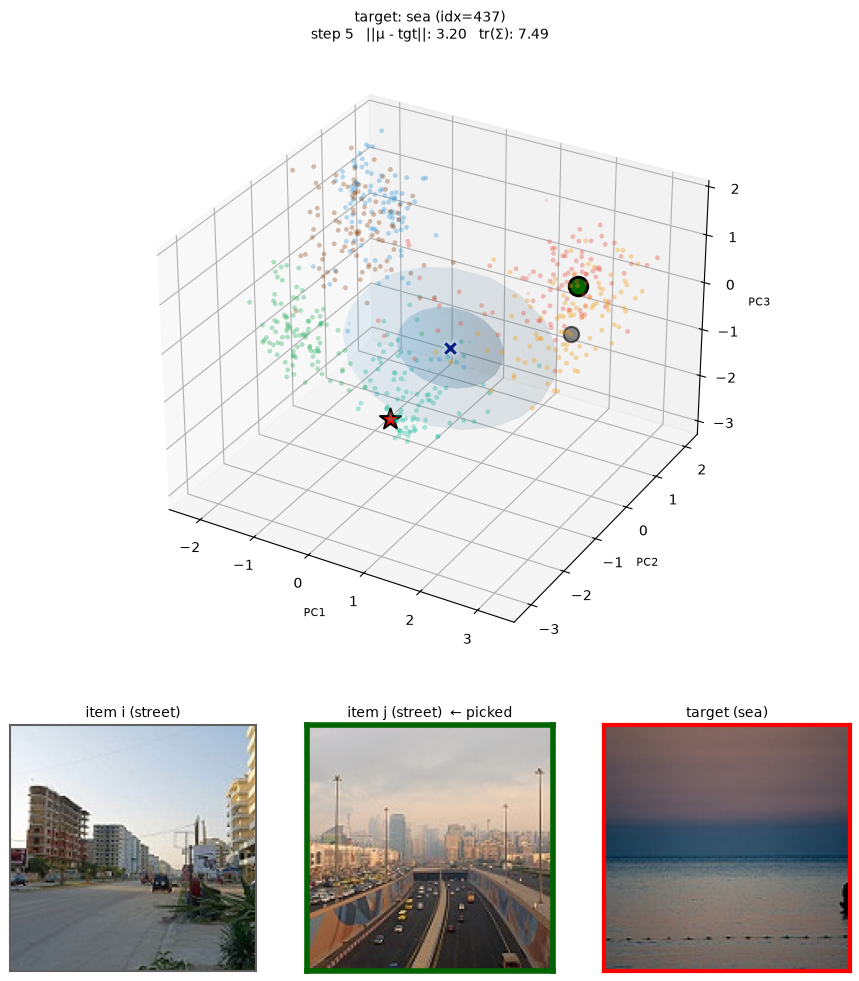

In [29]:
fig = plt.figure(figsize=(11, 12))
plot_step_3d_with_images(fig, step=5, history=history, xyz_3d=xyz_3d,
                          target_idx=437, labels=labels, paths=paths,
                          pca_P_3d=pca_P_3d, pca_mean_3d=pca_mean_3d,
                          sigma_eps=SIGMA_EPS, X=X)
plt.show()

In [31]:
import os, tempfile, uuid
from IPython.display import Video

target_idx = 498
rng_trial = np.random.default_rng(seed=1000 + 40)
history = gauss_search_verbose(X, target_idx, SIGMA_EPS, max_queries=100,
                                rng=rng_trial, stop_on="in_query")
print(f"steps: {history['step_stopped']}")

anim, fig = make_3d_animation_with_images(
    history, xyz_3d, target_idx, labels, paths,
    pca_P_3d, pca_mean_3d, SIGMA_EPS, X, interval_ms=1500)

out_path = os.path.join(tempfile.gettempdir(), f"scenery_3d_images_{uuid.uuid4().hex[:8]}.mp4")
anim.save(out_path, writer='ffmpeg', fps=0.4, dpi=100)
plt.close(fig)
print(f"saved to {out_path}")
Video(out_path, embed=True, width=800)

steps: 29
saved to C:\Users\shlok\AppData\Local\Temp\scenery_3d_images_12d9ef39.mp4


In [33]:
import os, tempfile, uuid
from IPython.display import Video

target_idx = 437
rng_trial = np.random.default_rng(seed=1000 + 40)
history = gauss_search_verbose(X, target_idx, SIGMA_EPS, max_queries=100,
                                rng=rng_trial, stop_on="in_query")
print(f"steps: {history['step_stopped']}")

anim, fig = make_3d_animation_with_images(
    history, xyz_3d, target_idx, labels, paths,
    pca_P_3d, pca_mean_3d, SIGMA_EPS, X, interval_ms=1500)

out_path = os.path.join(tempfile.gettempdir(), f"scenery_3d_images_{uuid.uuid4().hex[:8]}.mp4")
anim.save(out_path, writer='ffmpeg', fps=0.4, dpi=100)
plt.close(fig)
print(f"saved to {out_path}")
Video(out_path, embed=True, width=800)

steps: 14
saved to C:\Users\shlok\AppData\Local\Temp\scenery_3d_images_f911731a.mp4


In [34]:
import numpy as np
from collections import defaultdict

labels_arr = np.array(labels)
gauss_iq_arr = np.array(gauss_iq_steps)

print(f"  {'class':<10s}  mean   median   p95   max")
for cls in sorted(np.unique(labels_arr)):
    mask = labels_arr == cls
    cls_steps = gauss_iq_arr[mask]
    print(f"  {cls:<10s}  {cls_steps.mean():5.1f}  {np.median(cls_steps):5.1f}   "
          f"{np.percentile(cls_steps, 95):5.1f}  {cls_steps.max():3d}")

# overall row too
print(f"  {'ALL':<10s}  {gauss_iq_arr.mean():5.1f}  {np.median(gauss_iq_arr):5.1f}   "
      f"{np.percentile(gauss_iq_arr, 95):5.1f}  {gauss_iq_arr.max():3d}")

  class       mean   median   p95   max
  buildings    14.7   15.0    25.0   27
  forest       18.9   19.0    32.0   37
  glacier      18.3   18.0    32.0   43
  mountain     16.9   16.0    29.0   36
  sea          14.7   15.0    25.0   35
  street       17.6   18.0    26.0   34
  ALL          16.9   17.0    29.0   43
